# ⚽ Segmentación de jugadores de fútbol (5 grandes ligas europeas, 2025-26)
## Clustering de perfiles **por posición** — Protocolo CRISP-DM

Construye **cuatro modelos de clustering independientes**, uno por posición: porteros (GK), defensas (DF), mediocampistas (MF) y delanteros (FW).

| | |
|---|---|
| **Datos** | La Liga, Ligue 1, Premier League, Serie A y Bundesliga · temporada 2025-26 |
| **Fuente** | FBref vía `soccerdata`, tabla combinada de las 5 grandes ligas |
| **Tablas** | `standard`, `shooting`, `playing_time`, `misc`, `keeper` |
| **Resultado** | **15 perfiles**: 3 en GK, 3 en DF, 4 en MF, 5 en FW |

**Estructura**

| Sección | Contenido | Fase CRISP-DM |
|---|---|---|
| 1 | Comprensión del negocio | 1 |
| 2 | Comprensión de los datos | 2 |
| 3 | Preparación común: filtros, 4 datasets y funciones reutilizables | 3 |
| 4 | Modelo de **porteros (GK)** | 3 · 4 · 5 |
| 5 | Modelo de **defensas (DF)** | 3 · 4 · 5 |
| 6 | Modelo de **mediocampistas (MF)** | 3 · 4 · 5 |
| 7 | Modelo de **delanteros (FW)** | 3 · 4 · 5 |
| 8 | Evaluación comparativa y despliegue | 5 · 6 |

- Fases **1 y 2**: comunes a las cuatro posiciones (mismo origen de datos).
- Desde la **fase 3**: cada posición sigue su propio camino — variables, escalado, `k` y modelo propios.

> El proyecto se construyó primero sobre 2023-24 y se migró a 2025-26. La comparación entre ambas está en las conclusiones: el esquema de variables aguantó sin cambios, pero **la numeración de los clusters y parte de la estructura no**.

---
## 1. Comprensión del negocio (*Business Understanding*)

### Objetivo

Identificar de forma no supervisada **arquetipos de jugadores dentro de cada posición**, a partir de métricas de rendimiento por 90 minutos.

### Por qué un modelo por posición y no uno global

- Un clustering único gasta sus primeros cortes en **redescubrir la posición** (separa delanteros de defensas), algo que ya dice la columna `pos`.
- Segmentando **dentro** de cada línea, el modelo debe distinguir *roles*: central agresivo vs. central de salida, extremo centrador vs. nueve de área, pivote de corte vs. interior llegador.
- Cada línea se juzga con **métricas distintas**: el % de parada solo aplica a un portero; los centros solo describen un rol en bandas.

### Qué miden los datos

| Bloque | Métricas |
|---|---|
| Producción ofensiva | goles, asistencias, goles sin penalti (por 90) |
| Volumen de remate | tiros y tiros a puerta por 90 |
| Juego por bandas | centros por 90 |
| Aporte defensivo | intercepciones, entradas ganadas |
| Disciplina y roce | faltas cometidas y recibidas, tarjetas, fueras de juego |
| Portería (`keeper`) | goles encajados, paradas, % de parada, tiros a puerta en contra, porterías a cero |

> ⚠️ **No hay** xG, pases progresivos ni duelos aéreos. Para porteros tampoco PSxG, salidas del área ni juego con los pies. Requeriría añadir `passing`, `possession`, `defense` o `keeper_adv` en la recolección para unos datos más completos.

### Usos del resultado

- **Scouting**: encontrar perfiles similares a uno dado *dentro de su posición* (sustitutos, objetivos de fichaje).
- **Comparación** entre jugadores que comparten posición pero cumplen roles distintos.
- Detectar **atípicos** que no encajan en ningún perfil dominante de su línea.

### Criterios de éxito

- **Interpretables**: cada cluster admite un nombre futbolístico con sentido.
- **Más finos que la posición**: si dentro de los defensas no distinguen roles, el modelo no sirve.
- **Estables** ante cambios pequeños en los datos — *no medido en este notebook*, queda como trabajo futuro (sección 8).

### Decisiones metodológicas

- **Un clustering independiente por posición**, cada uno con sus variables, su escalado y su `k`.
- Los **porteros entran** con modelo propio basado en `keeper`; no se mezclan con jugadores de campo porque sus métricas no son comparables.
- Un **polivalente** (`"DF,MF"`, `"MF,FW"`...) se evalúa **en los dos datasets**: su perfil como defensa y como mediocampista son preguntas distintas.
- **Dos umbrales de minutos** (detalle en 3.1):
  - *Entrenamiento* — quién define los perfiles: **10 partidos completos** (15 en porteros).
  - *Inclusión* — quién recibe etiqueta: **5 partidos**, marcando su confianza.
  - Así los arquetipos salen de datos fiables sin dejar fuera al suplente ni al juvenil, que son el caso de uso natural del scouting.

---
## 2. Comprensión de los datos (*Data Understanding*)

### 2.1 Recolección

Descarga de FBref las tablas `standard`, `shooting`, `playing_time`, `misc` y `keeper`, las une y guarda un CSV local.

- **`keeper` habilita el modelo de porteros** (sección 4): goles encajados, paradas, % de parada, tiros a puerta en contra, porterías a cero.
- Los jugadores de campo tienen esas columnas vacías, y los porteros no tienen métricas de remate. Es esperado: **cada modelo usa solo las columnas de su posición**, así que los vacíos de una nunca llegan a otra.
- El CSV funciona como **caché**. Para volver a descargar: `recolectar_datos_permitidos(forzar_descarga=True)`.

In [1]:
import _bootstrap  # noqa: F401 — pone la raíz del proyecto en sys.path

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from config import parametros as P
from config import rutas as R
from src import datos, modelado, preparacion, visualizacion
from src.utils import mostrar

# La descarga vive en src/datos.py. Guarda el resultado en data/raw/ y en las siguientes
# ejecuciones lo lee de ahí, así que este notebook no vuelve a golpear a FBref.
print(f"Ligas:     {P.FBREF_LIGAS}")
print(f"Temporada: {P.FBREF_TEMPORADAS}")
print(f"Tablas:    {P.FBREF_TABLAS}")
print(f"Caché:     {R.CSV_CRUDO.relative_to(R.RAIZ)}")

Ligas:     ['Big 5 European Leagues Combined']
Temporada: ['2526']
Tablas:    ['standard', 'shooting', 'playing_time', 'misc', 'keeper']
Caché:     data\raw\datos_jugadores_2526.csv


In [2]:
df_raw = datos.recolectar_datos_permitidos()

print(f"\nDatos cargados: {df_raw.shape[0]} jugadores, {df_raw.shape[1]} columnas.")
df_raw.head()

📂 Cargando datos desde caché local: 'datos_jugadores_2526.csv'

Datos cargados: 3536 jugadores, 75 columnas.


,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,ENG-Premier League,2526,Arsenal,Ben White,ENG,DF,27.0,1997.0,12.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ENG-Premier League,2526,Arsenal,Bukayo Saka,ENG,"FW,MF",23.0,2001.0,31.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ENG-Premier League,2526,Arsenal,Christian Nørgaard,DEN,MF,31.0,1994.0,7.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ENG-Premier League,2526,Arsenal,Cristhian Mosquera,ESP,DF,21.0,2004.0,20.0,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ENG-Premier League,2526,Arsenal,David Raya,ESP,GK,29.0,1995.0,37.0,37.0,...,25.0,7.0,5.0,19.0,51.4,0.0,0.0,0.0,0.0,NaN


### 2.2 Exploración inicial

Tamaño, tipos de dato, faltantes y descriptivos básicos — el paso estándar de *Data Understanding* antes de tocar nada.

In [3]:
print("Dimensiones:", df_raw.shape)
print("\nTipos de dato:")
print(df_raw.dtypes.value_counts())


Dimensiones: (3536, 75)

Tipos de dato:
float64    65
str         5
int64       5
Name: count, dtype: int64


In [4]:
faltantes = df_raw.isna().mean().sort_values(ascending=False) * 100
faltantes = faltantes[faltantes > 0]
print(f"Columnas con datos faltantes: {len(faltantes)} de {df_raw.shape[1]}")

# Columnas 100% vacías: FBref las trae en la cabecera pero sin ningún valor.
# No aportan nada al modelo y además rompen la imputación, así que se descartan en la fase 3.
cols_vacias = faltantes[faltantes == 100].index.tolist()
print(f"Columnas completamente vacías (se descartarán): {cols_vacias}")

faltantes.head(20)


Columnas con datos faltantes: 68 de 75
Columnas completamente vacías (se descartarán): ['Performance_PKwon', 'Performance_PKcon']


Performance_PKwon      100.000000
Performance_PKcon      100.000000
Penalty Kicks_Save%     96.097285
Performance_CS%         94.683258
Performance_Save%       94.626697
Penalty Kicks_PKatt     94.513575
Performance_CS          94.513575
Performance_D           94.513575
Performance_L           94.513575
Penalty Kicks_PKA       94.513575
Penalty Kicks_PKsv      94.513575
Penalty Kicks_PKm       94.513575
Performance_Saves       94.513575
Performance_SoTA        94.513575
Performance_GA          94.513575
Performance_W           94.513575
Performance_GA90        94.513575
Standard_G/SoT          43.071267
Standard_G/Sh           33.597285
Standard_SoT%           33.597285
dtype: float64

In [5]:
df_raw.describe(include='number').T.head(15)


,count,mean,std,min,25%,50%,75%,max
season,3536.0,2526.000000,0.000000,2526.0,2526.00,2526.0,2526.0,2526.0
age,2837.0,24.855834,4.623789,15.0,21.00,25.0,28.0,41.0
born,2837.0,1999.802256,4.633160,1983.0,1997.00,2000.0,2003.0,2010.0
Playing Time_MP,2839.0,19.131032,11.517815,1.0,9.00,20.0,29.0,38.0
Playing Time_Starts,2839.0,13.568862,11.221429,0.0,3.00,12.0,23.0,38.0
Playing Time_Min,2839.0,1217.882705,962.854097,1.0,319.00,1074.0,1972.5,3420.0
Playing Time_90s,2839.0,13.532124,10.699148,0.0,3.55,11.9,21.9,38.0
Performance_Gls,2839.0,1.660092,2.931866,0.0,0.00,0.0,2.0,36.0
Performance_Ast,2839.0,1.159211,1.832680,0.0,0.00,0.0,2.0,21.0
Performance_G+A,2839.0,2.819303,4.133531,0.0,0.00,1.0,4.0,41.0


---
## 3. Preparación de los datos (*Data Preparation*) — parte común

Solo lo que es **igual para las cuatro posiciones**, más las piezas que cada una reutilizará.

**1 · Filtro base**
- Se descartan las filas sin datos (plantilla que no llegó a jugar: FBref las trae con `pos` y minutos vacíos) y quienes no llegan a 450 minutos.
- Dentro de cada dataset se marca quién **entrena** el modelo y quién solo recibe etiqueta — dos umbrales distintos, justificados en 3.1.

**2 · Separación en 4 datasets**
- FBref reporta la posición como texto (`"MF"`, `"MF,FW"`, `"DF,MF"`...), así que se busca el código como **subcadena, no por igualdad**.
- Un polivalente entra en los **dos** datasets que le corresponden.
- La suma de los cuatro datasets supera al total de jugadores, y es correcto: cada aparición responde a una pregunta distinta.

**3 · Diccionario `FEATURES`**
- Lo que define el perfil de un portero no es lo que define el de un extremo, así que cada modelo recibe su propia lista de variables.

**4 · Funciones reutilizables** (fases 3, 4 y 5)

| Función | Qué hace |
|---|---|
| `preparar_features()` | totales a por-90 → imputación → escalado |
| `elegir_k()` | método del codo + coeficiente de silueta |
| `proyectar_pca()` | proyección a 3 componentes, en 3D y en sus tres planos |
| `ajustar_y_evaluar()` | K-Means final, silueta, PCA, perfil de cada cluster y representativos |

**5 · Evidencia de las tres decisiones** (3.1 a 3.3): por qué el umbral de minutos es distinto en cada posición, por qué el escalado es Yeo-Johnson y qué aporta cada variable. Cada bloque explica qué calcula su celda y termina en una figura.

A partir de la sección 4, **cada posición corre su propia fase 3, 4 y 5** con estas funciones.

In [6]:
# Los dos umbrales están en config/parametros.py, con el razonamiento de cada corte.
# Un solo sitio donde cambiarlos: este notebook, los cuatro modelos y el dashboard los
# leen de ahí, y antes estaban escritos por triplicado.
print(f"Inclusión (quién recibe etiqueta):  {P.MINUTOS_INCLUSION} min "
      f"= {P.MINUTOS_INCLUSION // P.PARTIDO} partidos, igual para las cuatro posiciones\n")
print("Entrenamiento (quién define los perfiles):")
for pos in P.POSICIONES:
    print(f"  {P.NOMBRE_POS[pos]:15s} {P.MINUTOS_ENTRENAMIENTO[pos]:5d} min "
          f"= {P.MINUTOS_ENTRENAMIENTO[pos] // P.PARTIDO:2d} partidos")
print()

# --- 1) Filtro base: relleno de la Bundesliga + filas sin posición ---
df_base = datos.cargar_base(df_raw)

# --- 2) Separación en 4 datasets ---
datasets = preparacion.construir_datasets(df_base)

# --- 3) Universo analizado, cobertura de scouting y polivalentes ---
analizados, polivalentes = preparacion.universo_analizado(df_base, datasets)

Inclusión (quién recibe etiqueta):  450 min = 5 partidos, igual para las cuatro posiciones

Entrenamiento (quién define los perfiles):
  Porteros         1350 min = 15 partidos
  Defensas          900 min = 10 partidos
  Mediocampistas    900 min = 10 partidos
  Delanteros        900 min = 10 partidos

Etiquetados como GER-Bundesliga: 18 equipos, 595 filas (Augsburg, Bayern Munich, Dortmund, Frankfurt...)
Jugadores en el CSV:                    3536
  - sin posición / sin minutos jugados: 697
Jugadores con posición registrada:      2839



--- Los 4 datasets (inclusión: 450 min) ---
código       posición umbral_entren.  n_etiquetados  n_entrenan  n_conf_baja  % conf. baja
    GK       Porteros       15 part.            139         105           34          24.0
    DF       Defensas       10 part.            735         605          130          18.0
    MF Mediocampistas       10 part.           1143         878          265          23.0
    FW     Delanteros       10 part.            511         380          131          26.0

--- Reparto por liga (jugadores en al menos un modelo) ---
league
ITA-Serie A           438
ESP-La Liga           426
ENG-Premier League    405
FRA-Ligue 1           372
GER-Bundesliga        357

Jugadores de 21 años o menos con etiqueta: 322 de 1998 analizados

Suma de los 4 datasets: 2528 apariciones para 1998 jugadores distintos
Jugadores polivalentes: 530
pos
MF,FW    204
DF,MF    121
FW,MF    107
MF,DF     98


In [7]:
# Las cuatro listas de variables están en config/parametros.py, cada una con el
# comentario de qué capta y por qué quedaron fuera las demás candidatas.
print("Variables por modelo:\n")
for pos in P.POSICIONES:
    faltan = [c for c in P.FEATURES[pos] if c not in df_raw.columns]
    aviso = f"   ⚠️ NO ESTÁN EN EL CSV: {faltan}" if faltan else ""
    print(f"  {P.NOMBRE_POS[pos]:15s} n={len(datasets[pos]):4d}  "
          f"{len(P.FEATURES[pos]):2d} variables · k={P.K_ELEGIDO[pos]}{aviso}")

# La misma variable puede aparecer en varias posiciones (Performance_Int está en DF, MF y
# FW). Cada modelo la escala con la media y la desviación DE SU PROPIO dataset, así que
# "muchas intercepciones" mide algo distinto en cada línea: un defensa se compara contra
# defensas y un delantero contra delanteros. Es justo lo que un clustering global no hace.
mostrar(pd.DataFrame({
    "posición": [P.NOMBRE_POS[p] for p in P.POSICIONES],
    "variables": [len(P.FEATURES[p]) for p in P.POSICIONES],
    "k": [P.K_ELEGIDO[p] for p in P.POSICIONES],
    "etiquetados": [len(datasets[p]) for p in P.POSICIONES],
    "entrenan": [int(datasets[p]["entrena"].sum()) for p in P.POSICIONES],
}).set_index("posición"))

Variables por modelo:

  Porteros        n= 139   5 variables · k=3
  Defensas        n= 735   8 variables · k=3
  Mediocampistas  n=1143  10 variables · k=4
  Delanteros      n= 511  10 variables · k=5


,variables,k,etiquetados,entrenan
posición,,,,
Porteros,5,3,139,105
Defensas,8,3,735,605
Mediocampistas,10,4,1143,878
Delanteros,10,5,511,380


In [8]:
# Las piezas que reutilizan las cuatro posiciones ya no viven en este notebook: están en
# src/, y aquí solo se importan. Así el informe, los cuatro modelos y el dashboard
# ejecutan exactamente el mismo código, y cambiar una cosa la cambia en los tres sitios.
#
#   src/preparacion.py   preparar_features()   por-90 → imputación → escalado (fase 3)
#                        construir_datasets()  separación en las cuatro posiciones
#   src/modelado.py      ajustar_y_evaluar()   K-Means + silueta + perfiles (fases 4 y 5)
#                        exportar()            CSV + tabla de perfiles + .joblib (fase 6)
#   src/visualizacion.py elegir_k()            codo + silueta
#                        proyectar_pca()       nube 3D + los tres planos
#                        figura_descartadas()  por qué quedó fuera cada candidata
#
# Lo esencial de la fase 3, que es común a los cuatro modelos: el imputer y el scaler se
# ajustan SOLO con los jugadores de entrenamiento y luego se aplican a todos. Así la
# escala con la que se mide a todo el mundo sale de tasas bien medidas, y un juvenil con
# 600 minutos no la desplaza.
print(preparar := preparacion.preparar_features.__doc__.split("\n")[0])
print(f"\n  escalado por defecto : {P.ESCALADO}")
print(f"  divisor por-90       : {P.COL_90S}")
print(f"  semilla              : {P.RANDOM_STATE}   ·   n_init: {P.N_INIT}")

Fase 3 para el dataset de UNA posición: por-90 → imputación → escalado.

  escalado por defecto : yeo-johnson
  divisor por-90       : Playing Time_90s
  semilla              : 42   ·   n_init: 10


---
### 3.1 · Decisión 1 — el umbral de minutos

**El problema.** Un promedio "por 90" hecho sobre pocos partidos no es fiable: si un defensa juega 5 partidos y hace 6 intercepciones, repetir esos mismos 5 partidos podría darle 3 o 9. Pero excluir a esos jugadores tampoco sirve, porque el juvenil con 600 minutos es justo a quien quiere mirar un departamento de scouting.

**La salida** es separar las dos preguntas en dos umbrales:

| Umbral | Qué decide | Regla |
|---|---|---|
| **Entrenamiento** | Quién **define** los perfiles: ajusta `imputer`, `scaler`, centroides y ejes de la PCA | **10 partidos** completos · **15** en porteros |
| **Inclusión** | Quién **recibe** una etiqueta, vía `kmeans.predict` contra centroides que no ayudó a construir | **5 partidos** completos |

Cada jugador queda marcado con `confianza` (*alta* si entrenó, *baja* si solo fue etiquetado).

**Por qué esos números.** Son **cortes convencionales**, no un parámetro optimizado: los filtros de minutos mínimos en análisis de fútbol se mueven habitualmente entre 5 y 10 partidos. Cada uno tiene un ancla interpretable:

- **5 partidos** — mínimo para no ser puro relleno; una rotación esporádica.
- **10 partidos** — titular habitual, aproximadamente media temporada de juego.
- **15 partidos (porteros)** — sus variables son **porcentajes** (`Save%`, `CS%`), y un porcentaje sobre pocos partidos es muy inestable: es como juzgar a un tirador por una sola noche de tiros libres. Con 15 partidos acumula ~67 tiros a puerta recibidos, un denominador razonable.

**Qué calcula la celda siguiente.**

- **(a)** Aplica la regla y cuenta en qué tramo cae cada jugador: descartado, confianza baja, o entrenamiento.
- **(b)** La prueba que importa: **repite el clustering completo variando el umbral** de 6 a 18 partidos y mide el **ARI** de cada versión contra la elegida. Si la partición aguanta al mover el corte, la elección exacta deja de ser un problema.

**Lo que muestra la sensibilidad.** La franja sombreada marca **±2 partidos** alrededor del corte:

- **Mediocampistas:** ARI por encima de 0.94 en todo el rango 6-15. Es el modelo más estable de los cuatro.
- **Defensas y delanteros:** la partición aguanta dentro de la banda 8-12 (ARI ≥ 0.82). Fuera de ella el conjunto de entrenamiento cambia demasiado y los grupos se reordenan.
- **Porteros:** no hay plató. Con ~100 jugadores y una silueta de 0.19, ese modelo se mueve ante cualquier cambio.

> ⚠️ **La conclusión honesta** no es "el umbral da igual", sino: **mover el corte ±2 partidos no cambia los perfiles** en las tres posiciones de campo. En porteros la partición es frágil por el tamaño de la muestra, no por el umbral — es el modelo más delicado de los cuatro, como ya se advierte en la sección 4, y su corte más alto responde a la naturaleza de sus variables, no a un ajuste fino.
>
> ⚠️ **Lo que ningún umbral arregla.** Variables intrínsecamente raras: las amarillas de un defensa (0.22 por 90) o los goles de un central (0.05 por 90) son demasiado escasas en una temporada para estabilizarse con cualquier corte razonable.

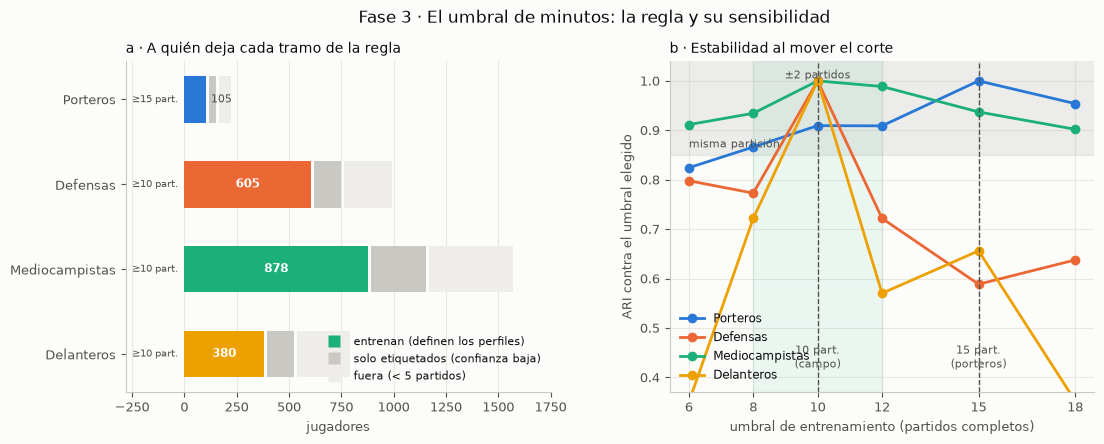

In [9]:
# ===== Evidencia de la decisión 1: el umbral de minutos =====
# (a) a quién deja cada tramo de la regla · (b) ARI al mover el corte de entrenamiento
visualizacion.figura_umbral(df_base, datasets,
                            guardar=R.figura("31_umbral_minutos.png"))

---
### 3.2 · Decisión 2 — el escalado

**El problema.** K-Means mide distancias euclídeas, así que **una sola variable puede dominar la partición** si su cola es más larga que la del resto. Las tasas por 90 son conteos divididos entre minutos: muchos ceros y cola derecha larga.

**Las dos opciones:**

- `StandardScaler` — centra y divide por la desviación. Iguala la escala, **no** la asimetría.
- `PowerTransformer(yeo-johnson, standardize=True)` — simetriza primero y estandariza después.

**Qué calcula la celda siguiente.** Toma el dataset de defensas —el caso más extremo—, aplica los dos escalados sobre las mismas tasas por 90 y compara:

- **(a) y (b)** la distribución de la variable más sesgada con cada escalado.
- **(c)** el **máx |z|** de cada variable con ambos. Ese es el criterio: mide a cuántas desviaciones queda el jugador más extremo y, por tanto, cuánto puede tirar él solo de un centroide. Cuanto más parejos los máx |z| entre variables, más equilibrado el peso de cada una en la distancia.

El resultado en defensas: la **asimetría media** de sus 8 variables pasa de **1.19** en bruto a **1.19** con `StandardScaler` —estandarizar no la toca— y a **0.04** con Yeo-Johnson.

> El pico de la izquierda en el panel (b) son los defensas con **cero asistencias**: ninguna transformación puede repartir una masa puntual. Lo que sí hace Yeo-Johnson es recortar la cola opuesta, que es la que desplazaba centroides.

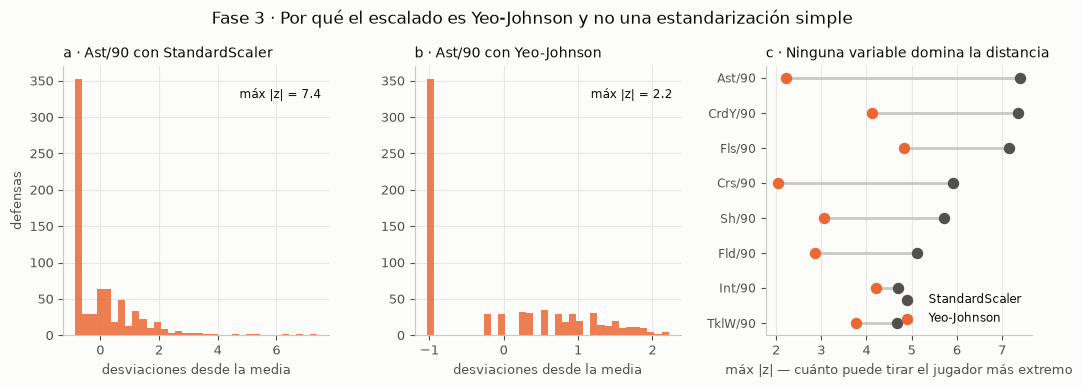

In [10]:
# ===== Evidencia de la decisión 2: el escalado =====
# La misma variable con StandardScaler y con Yeo-Johnson, y el máx |z| de todas.
visualizacion.figura_escalado(datasets, guardar=R.figura("32_escalado.png"))

---
### 3.3 · Decisión 3 — qué variables entran en cada modelo

**El problema.** Una variable puede parecer relevante y no aportar nada a la partición. Si no separa, solo añade una dimensión de ruido a la distancia euclídea.

**Qué calcula la celda siguiente.** Para cada posición, sobre el conjunto **candidato** (las variables del modelo más las que se probaron y quedaron fuera):

1. Ajusta el K-Means con todas las candidatas → partición de referencia.
2. Quita una variable, reajusta, y mide el **ARI** contra esa referencia.
3. ARI alto = los clusters no cambiaron = **la variable no estaba haciendo nada**.

El umbral práctico es **0.90**. Ojo con un detalle: la silueta casi siempre sube al quitar variables (menos dimensiones, menos concentración de distancias), así que el criterio es el ARI, no la silueta.

**Qué se ve en la figura.** Solo dos barras superan 0.90, ambas en gris:

- `G-PK`/90 en **defensas** — un defensa marca 0.05 goles por 90, dos o tres por temporada, donde el rebote afortunado pesa tanto como el rol. `Ast`/90 tiene frecuencia parecida (0.06 por 90) y **sí se queda**: asistir desde el lateral es repetible de una forma en que marcar de córner no lo es.
- `SoT%` en **mediocampistas** — la puntería solo define un rol donde el volumen de tiro es alto y parejo. En una posición que va del pivote (0.84 tiros/90) al llegador (2.31), lo que separa es *cuánto* se tira. En delanteros se invierte, y por eso allí `SoT%` sí entra.

El resto de exclusiones (redundancia y sucesos demasiado raros) se justifica en la sección de cada posición, porque son argumentos de correlación y de frecuencia, no de esta prueba.

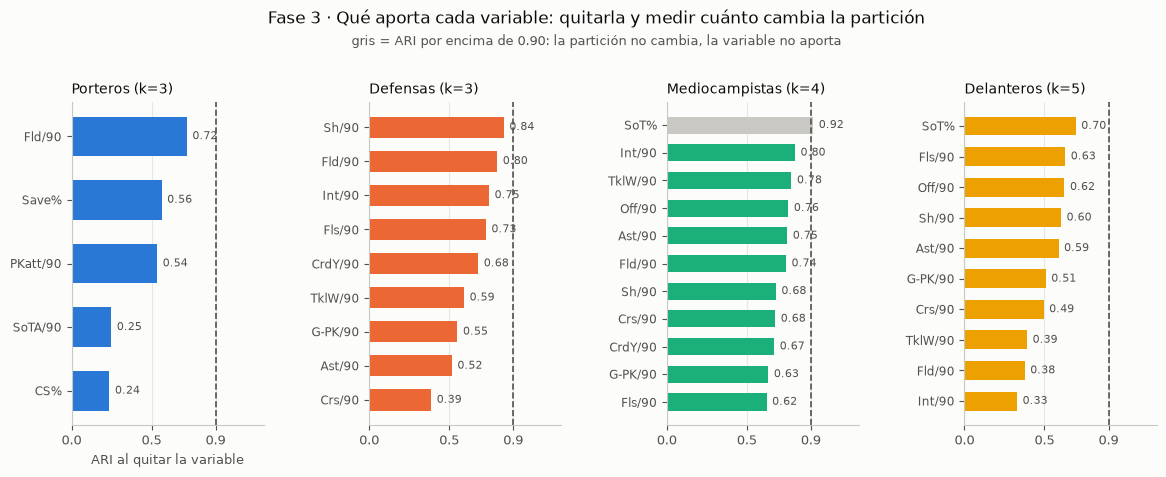

In [11]:
# ===== Evidencia de la decisión 3: qué variables entran =====
# Se quita cada candidata y se mide cuánto cambia la partición (ARI).
visualizacion.figura_ablacion(datasets, guardar=R.figura("33_ablacion_variables.png"))

---
## 4. Modelo de porteros (GK)

### Fase 3 · variables (5)

| Eje | Variables | Qué captura |
|---|---|---|
| **Carga de trabajo** | `SoTA`/90 | Cuántos tiros a puerta le llegan — de rebote, lo expuesto que está el equipo |
| **Habilidad** | `Save%` | Qué proporción de esos tiros detiene |
| **Resultado** | `CS%` | Partidos resueltos con la portería a cero |
| **Área** | `PKatt`/90, `Fld`/90 | Penaltis enfrentados y disputas en las que se le hace falta |

- **`Save%`** es la única que no depende de lo bien que defienda el equipo: correlaciona −0.17 con la carga de trabajo. Es el eje limpio de habilidad individual frente a tres ejes de contexto.
- **`Fld`/90** es un **proxy limitado** de cuánto sale el portero a disputar: no mide salidas directamente —esa métrica no está en `keeper` básica—, pero las faltas a un portero se producen casi siempre en balones aéreos y centros peleados. Es la variable más independiente del conjunto (correlación máxima 0.15) y el único indicio de *estilo* y no de resultado.

### Lo que queda fuera

Es la posición donde más cuesta elegir: casi todo lo que publica `keeper` mide el mismo fenómeno de fondo, lo que encaja el equipo.

| Variable | Motivo |
|---|---|
| `Saves`/90 | Correlaciona **0.93** con `SoTA`/90 — son los tiros recibidos por el % de parada |
| `GA90` | **0.83** con `CS%` y **0.69** con `Save%`: casi determinada por las otras |
| `Penalty Kicks_Save%` | 50 % de porteros en cero; con <5 penaltis por temporada salta entre 0 % y 100 % sin reflejar nivel |
| `Int`/90, `TklW`/90 | Habrían sido el proxy del portero-líbero, pero el 66 % no registra ninguna en la temporada |
| `W` / `D` / `L` | Describen el resultado del equipo, no la actuación del portero |

La figura siguiente lo muestra: `Saves`/90 y `GA90` rebasan la banda de **redundancia**, y `PK Save%`, `Int`/90 y `TklW`/90 la de **escasez**. `W`/`D`/`L` no aparecen porque su exclusión es conceptual —miden al equipo— y no hay métrica que la demuestre.

> ⚠️ **Limitación.** `keeper` básica no trae PSxG, ni salidas del área contabilizadas, ni juego con los pies. Este modelo separa por *cuánto se les exige* y *qué proporción resuelven*, no por estilo con balón. Perfilar "portero-líbero" vs. "portero de línea" requeriría `keeper_adv`.

### Fases 4-5

- Centroides ajustados con los **105 porteros de entrenamiento**; se etiqueta a los **139** que superan 450 minutos.
- Un `k` alto produciría grupos de una decena de jugadores: anécdota, no perfil.
- `k=3` deja los tres clusters con tamaño utilizable y es **el `k` más bajo en el que el eje de salidas al área aparece como grupo propio** — con `k=2` el modelo solo puede cortar por el eje de exigencia.

Dataset Porteros: 139 jugadores (105 de entrenamiento)
  3 de 5 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 139 jugadores × 5 variables (105 de entrenamiento, 34 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
SoTA/90,0.0,-0.29,-0.01,2.41,3.20
Save%,0.0,0.09,-0.00,2.76,5.62
CS%,5.0,0.29,0.00,2.86,4.15
PKatt/90,8.6,0.41,0.01,2.47,2.87
Fld/90,9.4,1.02,0.05,2.26,2.34


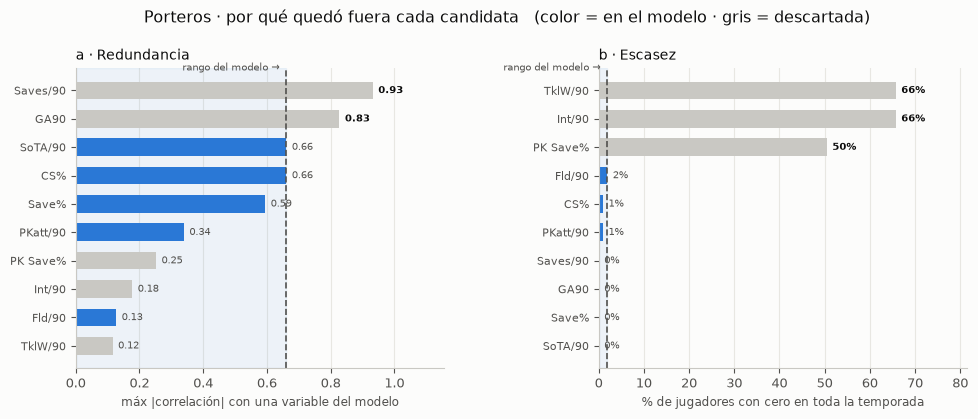

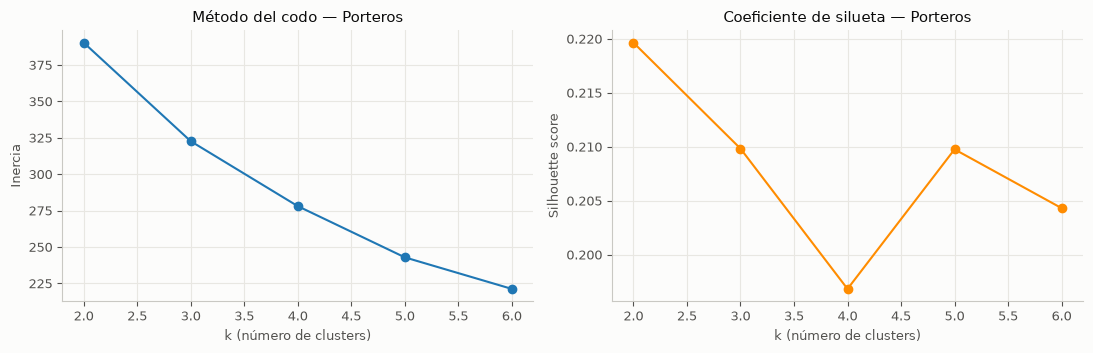

 k  inercia  silueta
 2    390.4    0.220
 3    322.7    0.210
 4    278.1    0.197
 5    242.9    0.210
 6    221.3    0.204

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 3

=== Porteros — k=3 | n=139 | silhouette=0.210 ===
    105 de entrenamiento (silueta 0.210) | 34 etiquetados por predicción (silueta del conjunto completo 0.179)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                 36        20
1                 33        24
2                 70        61


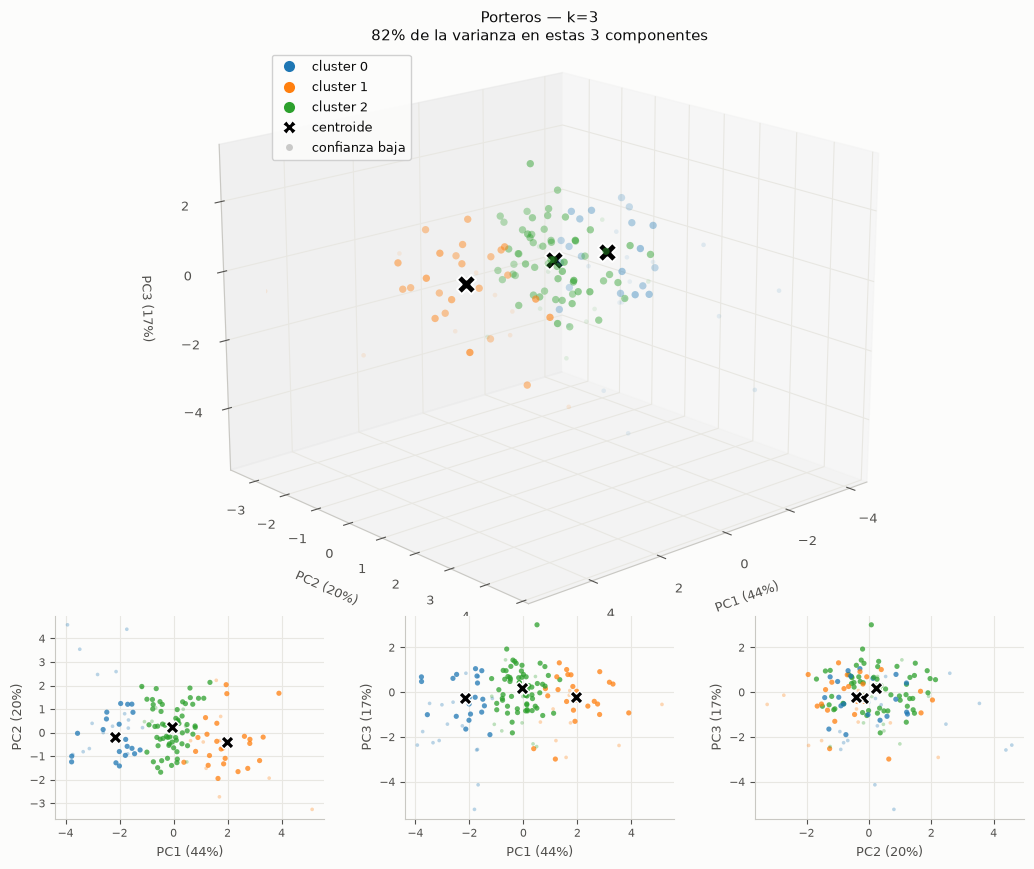

,varianza explicada,acumulada
PC1,44.3%,44.3%
PC2,19.9%,64.2%
PC3,17.5%,81.6%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
SoTA/90,-0.51,-0.08,0.38
Save%,0.43,-0.42,0.59
CS%,0.61,-0.17,0.08
PKatt/90,-0.38,-0.26,0.51
Fld/90,0.17,0.85,0.50


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2
SoTA/90,4.229,4.723,3.396,4.367
Save%,66.551,60.478,70.979,67.587
CS%,26.227,12.444,42.885,25.461
PKatt/90,0.154,0.211,0.102,0.150
Fld/90,0.171,0.146,0.145,0.196


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Leo Román, Julen Agirrezabala, Marvin Schwäbe, Daniel Heuer Fernandes, Frederik Rønnow, Yehvann Diouf
  cluster 1: Gregor Kobel, Jan Oblak, Michele Di Gregorio, Thibaut Courtois, Augusto Batalla, Robin Risser
  cluster 2: Wladimiro Falcone, Zion Suzuki, Dean Henderson, David de Gea, Matz Sels, Caoimhín Kelleher

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Marco Bizot,Aston Villa,34.0,585.0,2,0.95
1,Edoardo Motta,Lazio,20.0,810.0,1,1.05
2,Pau López,Real Betis,30.0,810.0,2,1.26
3,Jonas Urbig,Bayern Munich,21.0,1111.0,1,1.51
4,Giorgi Mamardashvili,Liverpool,24.0,867.0,0,1.52
5,Arnau Tenas,Villarreal,24.0,900.0,0,1.72
6,Maarten Vandevoordt,RB Leipzig,23.0,1052.0,2,1.79
7,Théo De Percin,Auxerre,24.0,598.0,0,2.17


Porteros        -> jugadores_GK_con_cluster.csv, perfil_clusters_GK.csv, modelo_GK.joblib


In [12]:
# ===== FASES 3 a 6 — el modelo de porteros de principio a fin =====
# El código está en models/modelo_gk.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_gk

modelos = {}   # se irá llenando en las secciones 4 a 7

modelos["GK"] = modelo_gk.main(datasets=datasets)

### Interpretación

**k=3 · silhouette 0.210** (105 de entrenamiento) · **0.179** (139 etiquetados) — el más alto de los cuatro modelos, como en 2023-24.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **1** | Portero de **bloque sólido** | 33 | Menor carga (`SoTA`/90 = 3.40 vs. media 4.23), mejor `Save%` (71.0 %), `CS%` 42.9 % vs. media 26.2 %, menos penaltis (0.102/90) | Kobel, Oblak, Di Gregorio, Courtois, Sommer |
| **0** | Portero **muy exigido** | 36 | Mayor carga (4.72), peor `Save%` (60.5 %), `CS%` 12.4 % — menos de un tercio del anterior —, más penaltis enfrentados (0.211/90) | Leo Román, Agirrezabala, Schwäbe, Rønnow, Vlachodimos |
| **2** | Portero **de área** | 70 | `Fld`/90 = **0.196 vs. 0.146 y 0.145**; carga, `Save%` y penaltis prácticamente en la media | Falcone, Suzuki, Henderson, De Gea, Sels, Kelleher |

**El cluster 2 es el que justifica el modelo.**
- Los clusters 0 y 1 son las dos puntas del eje de exigencia, que es en buena medida un eje de calidad de equipo.
- El 2 es lo único que se parece a un rasgo de **estilo**: no se define por lo que encaja sino por cuánto sale a disputar.
- Solo aparece porque los centroides se entrenan con porteros bien medidos; con las tasas ruidosas de quien lleva cinco partidos quedaba mezclado con los otros dos.

**La PCA lo confirma.**
- **PC1 (44.3 %)** — eje de exigencia y resultado: `CS%` (+0.61) y `Save%` (+0.43) contra `SoTA`/90 (−0.51).
- **PC2 (19.9 %)** — dominada por `Fld`/90 (**+0.85**): actividad en el área, con vida propia e independiente de lo que encaja el equipo. Ahí vive el cluster 2.

> ⚠️ **La separación del "portero de área" es más débil que en 2023-24.** Entonces su `Fld`/90 más que doblaba al de los otros dos (0.210 vs. 0.099 y 0.085) y el grupo tenía 44 porteros; ahora la ventaja es de un 34 % (0.196 vs. 0.146) y absorbe **la mitad de la posición** (70 de 139). El perfil sigue existiendo y la PCA lo respalda, pero es más un "resto con algo más de salida" que un arquetipo nítido. Conviene leerlo con esa reserva.

> ⚠️ **No es un ranking de calidad.** `CS%` y `SoTA`/90 dependen muchísimo del bloque defensivo. El indicador más individual sigue siendo `Save%`, y aun así conserva −0.17 con la carga recibida. Y salir mucho no es mejor ni peor que quedarse en la línea: es otra forma de defender el área.

**Uso para scouting.** Los 34 porteros de confianza baja son mayormente suplentes de temporada corta. La tabla de "mejor encajados en su perfil" los ordena por cercanía al centroide: los primeros son los de lectura de rol más limpia pese a la muestra corta.

---
## 5. Modelo de defensas (DF)

### Fase 3 · variables (8, todas por 90 minutos)

| Bloque | Variables |
|---|---|
| **Acción defensiva** | `Int`/90 (intercepciones), `TklW`/90 (entradas ganadas) |
| **Roce y disciplina** | `Fls`/90 (faltas cometidas), `Fld`/90 (recibidas), `CrdY`/90 (amarillas) |
| **Aporte ofensivo** | `Crs`/90 (centros), `Ast`/90, `Sh`/90 |

- El eje que más separa es **central vs. lateral**. `Crs`/90 es su marcador más nítido: media 1.42 con dispersión de 0 a casi 10.
- `Int`/90 y `CrdY`/90 marcan al central de área.
- **`Fls`/90 y `CrdY`/90 conviven** pese a correlacionar 0.52: miden volumen de falta y *gravedad*. Falta táctica lejos del área y llegar tarde dentro de ella dan `Fls`/90 parecido y `CrdY`/90 muy distinto.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `Off`/90 | Solo en esta posición: el **36 %** de los defensas no cae en fuera de juego ni una vez. En MF y FW sí entra |
| `SoT%` | La mediana de tiros a puerta de un defensa en la temporada es **3**: su puntería es accidente de muestra, no rasgo de rol |
| `G-PK`/90 | Se retiró con los datos de 2023-24 — **y con los de 2025-26 esa decisión ya no se sostiene** (ver abajo) |

En la figura siguiente, `SoT`/90 rebasa la banda de **redundancia** (0.84 con `Sh`/90) y `CrdR`/90 la de **escasez** (78 % de defensas sin ninguna roja). `Off`/90 y `SoT%` caben dentro de ambas bandas: su exclusión no es por redundancia ni por escasez, sino porque no separan roles.

**`G-PK`/90: una decisión que la nueva temporada desmiente.** Con 2023-24 la evidencia era clara —quitarla dejaba la partición casi idéntica (ARI 0.91) y subía la silueta de 0.152 a 0.172—, así que se retiró. Repetido sobre 2025-26:

| | 2023-24 | 2025-26 |
|---|---|---|
| ARI al quitarla | 0.91 — sin efecto | **0.55 — cambia la partición** |
| Silueta con ella | 0.152 | 0.143 |
| Silueta sin ella | **0.172** | 0.148 |

Sigue siendo cierto que la silueta mejora al quitarla, pero ya **no** es cierto que la partición no cambie: por el criterio de la sección 3.3 (umbral ARI 0.90), `G-PK`/90 ahora sí aporta. El modelo de esta sección mantiene las 8 variables originales para no alterar la comparación entre temporadas, pero **la decisión queda abierta**: rehacerla con `G-PK`/90 dentro es el primer experimento pendiente.

> Este dataset incluye a los polivalentes `DF,MF` y `MF,DF`, que también se evalúan en la sección 6 con variables de mediocampista.

### Fases 4-5

- La silueta sugiere `k=2` (0.183), correcto pero poco informativo: central vs. lateral ya lo sabíamos.
- Con **`k=3`** (0.148) el bloque de centrales se desdobla por estilo —posicional o de combate— sin que ningún grupo repita a otro.
- `k=4` baja a 0.129 sin aportar un rol nuevo.
- Centroides con los **605 de entrenamiento**; etiquetados **735**.

Dataset Defensas: 735 jugadores (605 de entrenamiento)


  6 de 8 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 735 jugadores × 8 variables (605 de entrenamiento, 130 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
Int/90,0.0,0.17,-0.01,3.12,4.21
TklW/90,0.1,0.58,0.00,3.08,3.76
Fls/90,0.1,0.48,-0.00,3.01,4.84
Fld/90,1.0,1.13,0.02,2.86,2.86
CrdY/90,7.1,0.62,0.01,2.76,4.13
Crs/90,8.6,1.66,0.21,1.97,2.04
Ast/90,48.0,1.40,0.28,2.15,2.22
Sh/90,1.5,1.28,0.01,3.07,3.07


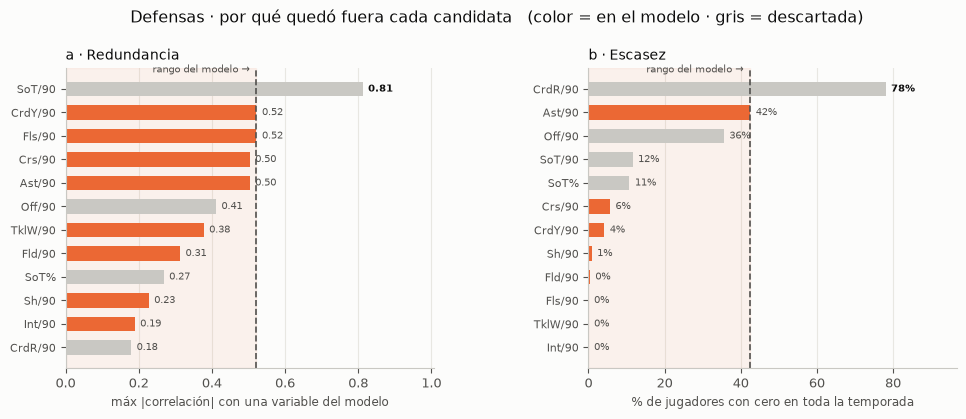

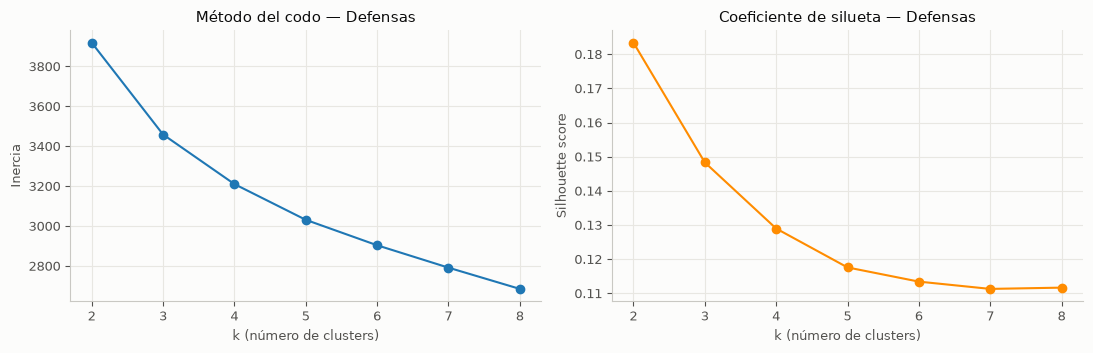

 k  inercia  silueta
 2   3919.1    0.183
 3   3458.8    0.148
 4   3210.4    0.129
 5   3031.3    0.118
 6   2903.8    0.113
 7   2791.7    0.111
 8   2685.2    0.112

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 3

=== Defensas — k=3 | n=735 | silhouette=0.148 ===
    605 de entrenamiento (silueta 0.148) | 130 etiquetados por predicción (silueta del conjunto completo 0.149)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                235       195
1                250       192
2                250       218


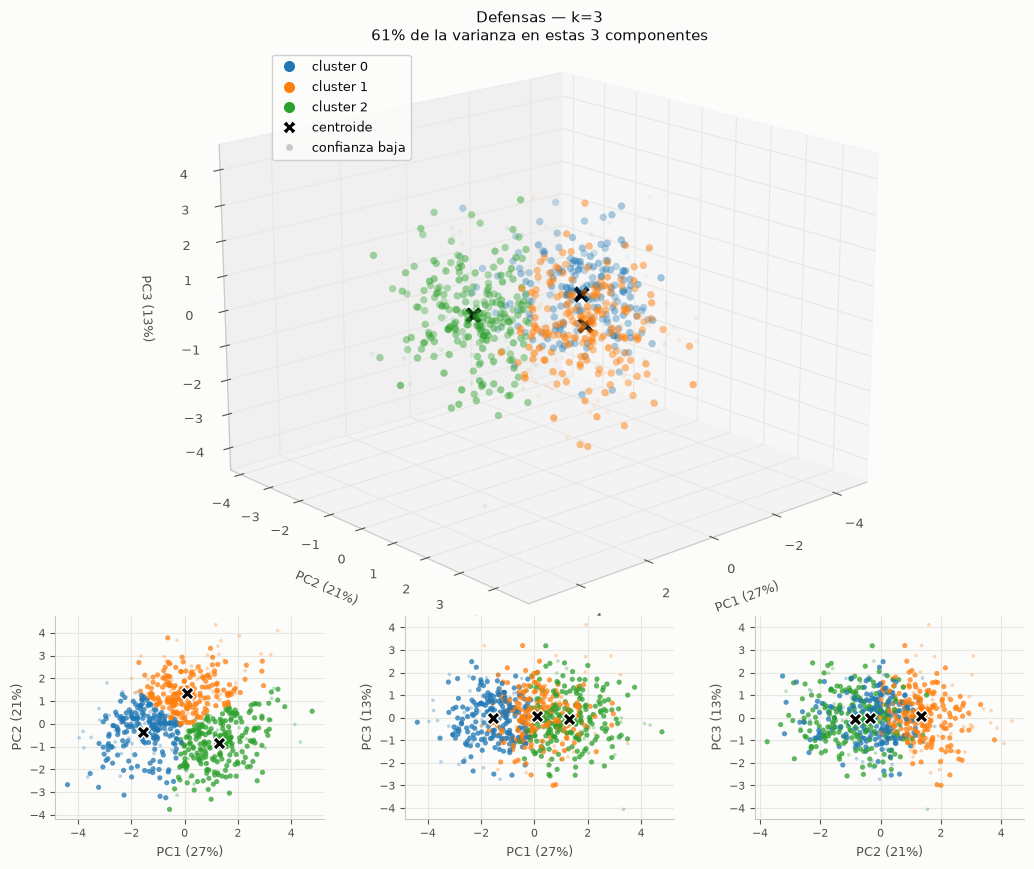

,varianza explicada,acumulada
PC1,27.2%,27.2%
PC2,21.0%,48.3%
PC3,12.6%,60.8%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
Int/90,0.00,0.41,0.72
TklW/90,0.43,0.11,0.33
Fls/90,0.38,0.44,-0.29
Fld/90,0.44,0.03,-0.11
CrdY/90,0.25,0.53,-0.29
Crs/90,0.47,-0.38,0.02
Ast/90,0.36,-0.40,-0.10
Sh/90,0.25,-0.17,0.43


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2
Int/90,1.077,0.989,1.312,0.925
TklW/90,1.085,0.808,1.163,1.267
Fls/90,1.085,0.772,1.360,1.105
Fld/90,0.794,0.516,0.810,1.039
CrdY/90,0.209,0.130,0.301,0.191
Crs/90,1.420,0.446,0.737,3.018
Ast/90,0.056,0.028,0.022,0.116
Sh/90,0.600,0.475,0.559,0.758


Composición de cada cluster por posición reportada (%):


pos,DF,"DF,MF","MF,DF"
cluster,,,
0,89.8,6.8,3.4
1,76.8,14.4,8.8
2,45.2,27.6,27.2


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Joachim Andersen, Trevoh Chalobah, Karol Mets, Jean-Philippe Gbamin, Santiago Bueno, Thomas Kristensen
  cluster 1: Daniel Vivian, Keven Schlotterbeck, Valentín Gómez, Robert Andrich, Unai Núñez, Lautaro Valenti
  cluster 2: Jayden Bogle, Pep Chavarría, Álex Moreno, Johan Mojica, Nordi Mukiele, Arnau Martinez

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Junior Firpo,Real Betis,28.0,827.0,2,1.10
1,Rubén,Espanyol,24.0,812.0,2,1.27
2,Luke O'Nien,Sunderland,30.0,569.0,2,1.32
3,Iván Balliu,Rayo Vallecano,33.0,582.0,1,1.40
4,Francisco Sierralta,Auxerre,28.0,861.0,0,1.61
5,Isaac Schmidt,Werder Bremen,25.0,682.0,1,1.65
6,Jahmai Simpson-Pusey,Köln,19.0,863.0,0,1.79
7,Nathaniel Adjei,Lorient,22.0,835.0,0,1.84


Defensas        -> jugadores_DF_con_cluster.csv, perfil_clusters_DF.csv, modelo_DF.joblib


In [13]:
# ===== FASES 3 a 6 — el modelo de defensas de principio a fin =====
# El código está en models/modelo_df.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_df

modelos["DF"] = modelo_df.main(datasets=datasets)

### Interpretación

**k=3 · silhouette 0.148** (605 de entrenamiento) · **0.149** (735 etiquetados).

**La estructura cambió respecto a 2023-24.** Entonces el desdoble separaba dos tipos de *lateral* (de proyección y de combate) frente a un central. Ahora ocurre al revés: un solo grupo de laterales y **dos maneras de ser central**.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **2** | **Lateral ofensivo** | 250 | `Crs`/90 = 3.02 vs. media 1.42 y `Ast`/90 = 0.116, los más altos con diferencia. También lidera `TklW`/90 (1.27), `Fld`/90 (1.04) y `Sh`/90 (0.76). 54.8 % polivalentes `DF,MF` | Bogle, Chavarría, Álex Moreno, Mojica, Mukiele, Truffert |
| **1** | **Central de combate** | 250 | Máximos en `Int`/90 (1.31), `Fls`/90 (1.36) y `CrdY`/90 (0.301); mínimo absoluto en `Ast`/90 (0.022). Corta y se juega la tarjeta, sin aporte ofensivo | Vivian, Schlotterbeck, Valentín Gómez, Andrich, Unai Núñez |
| **0** | **Central posicional** | 235 | **Por debajo de la media en las ocho variables.** `TklW`/90 0.81, `Fls`/90 0.77, `Fld`/90 0.52, `CrdY`/90 0.130, `Crs`/90 0.45. 89.8 % `DF` puro, el más homogéneo | Joachim Andersen, Chalobah, Karol Mets, Santiago Bueno, Toti Gomes |

- **El contraste 0 vs. 1 es el hallazgo de esta temporada.** Los dos son centrales y los dos ocupan la misma zona, pero uno interviene y el otro no: el cluster 1 intercepta un 33 % más y comete un 76 % más de faltas que el 0. Es la diferencia entre defender anticipando y defender por posición.
- **El cluster 0 se define por ausencias**, lo cual es una lectura legítima pero frágil: un jugador puede caer ahí por rol o simplemente por jugar en un equipo que domina y apenas defiende.
- **`Crs`/90 y `Ast`/90 correlacionan 0.53** y juntas separan al lateral: es el par que sostiene el cluster 2.

**La PCA reparte la varianza más que en porteros.**
- **PC1 (27.2 %)** — eje ofensivo: `Crs`/90 (+0.47), `Fld`/90 (+0.44), `TklW`/90 (+0.43) contra nada en particular. Es el eje lateral ↔ central.
- **PC2 (21.0 %)** — eje de roce: `CrdY`/90 (+0.53), `Fls`/90 (+0.44), `Int`/90 (+0.41) contra `Ast`/90 (−0.40). Es el que separa a los dos centrales.

> ⚠️ Con silhouette 0.148 —más baja que el 0.172 de 2023-24— los límites son aún menos tajantes. Que la silueta del conjunto completo (0.149) sea igual a la de entrenamiento indica que los 130 defensas de confianza baja no caen peor que el resto: el problema no es la muestra corta, es que los roles de defensa forman un continuo.

---
## 6. Modelo de mediocampistas (MF)

### Fase 3 · variables (10)

Tensan el eje **destrucción ↔ creación ↔ llegada**, donde vive la variedad de roles del mediocampo.

| Bloque | Variables |
|---|---|
| **Recuperación** | `Int`/90, `TklW`/90 |
| **Roce** | `Fls`/90, `Fld`/90, `CrdY`/90 |
| **Creación** | `Ast`/90, `Crs`/90 |
| **Llegada / gol** | `G-PK`/90, `Sh`/90, `Off`/90 |

- Es la posición con más variables, y con razón: **`Int`/90 correlaciona −0.45 con `Sh`/90**, o sea que recuperar y rematar son polos opuestos de un mismo eje continuo. Hacen falta variables a ambos lados para situar a cada jugador en él.
- **`Fld`/90** es el mejor proxy de **conducción** disponible: a quien rompe líneas con el balón lo frenan a falta. Sin la tabla `possession` no hay regates ni conducciones progresivas.
- **`Off`/90** separa al mediapunta que ataca el área del interior que juega de cara; solo el 25 % nunca cae en fuera de juego, así que tiene recorrido suficiente.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `SoT`/90 | Correlaciona **0.91** con `Sh`/90: duplicaría el peso del volumen de remate |
| `SoT%` | **Estuvo dentro y se retiró** (ver abajo) |

En la figura siguiente, `SoT`/90 rebasa la banda de **redundancia** (0.91 con `Sh`/90), y `PKatt`/90 (85 %) y `CrdR`/90 (84 %) la de **escasez**. `SoT%` cabe dentro de ambas: se descartó por no aportar a la partición.

**Por qué se retiró `SoT%` — y por qué esta decisión sí aguanta.** A diferencia de `G-PK`/90 en defensas, aquí la evidencia se repite casi idéntica en las dos temporadas:

| | 2023-24 | 2025-26 |
|---|---|---|
| ARI al quitarla | 0.91 | **0.92** |
| Silueta con ella | 0.130 | 0.123 |
| Silueta sin ella | **0.141** | **0.133** |

- Es la variable de menor poder discriminante de las once que había (ARI 0.92, la más alta del conjunto).
- La puntería solo define un rol donde el volumen de tiro es alto y parejo. En una posición que va del pivote (0.79 tiros/90) al interior ofensivo (2.32), lo que separa es *cuánto* se tira, no *con qué acierto*.
- En delanteros la situación se invierte, y por eso allí `SoT%` sí entra.

> Es el dataset más grande de los cuatro: absorbe a todos los polivalentes `MF`, `MF,FW`, `FW,MF`, `DF,MF` y `MF,DF`.

### Fases 4-5

- Como en defensas, la silueta favorece `k=2` (0.211): ofensivo / defensivo.
- Con **`k=4`** (0.133) aparecen además el carrilero y el interior de conducción.
- Centroides con los **878 de entrenamiento**; etiquetados **1143**.

Dataset Mediocampistas: 1143 jugadores (878 de entrenamiento)


  7 de 10 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 1143 jugadores × 10 variables (878 de entrenamiento, 265 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
Int/90,1.0,0.64,0.01,2.97,3.31
TklW/90,0.3,0.65,0.00,2.94,3.37
Fls/90,0.0,0.62,-0.00,2.98,3.78
Fld/90,0.4,0.93,0.00,3.07,3.16
CrdY/90,10.8,0.64,0.02,3.13,3.67
Crs/90,1.5,0.98,-0.00,2.39,2.63
Off/90,28.9,1.96,0.26,2.13,2.20
Ast/90,25.5,1.40,0.09,2.70,2.70
G-PK/90,26.8,1.63,0.17,2.40,2.40
Sh/90,0.6,0.92,0.01,2.76,2.76


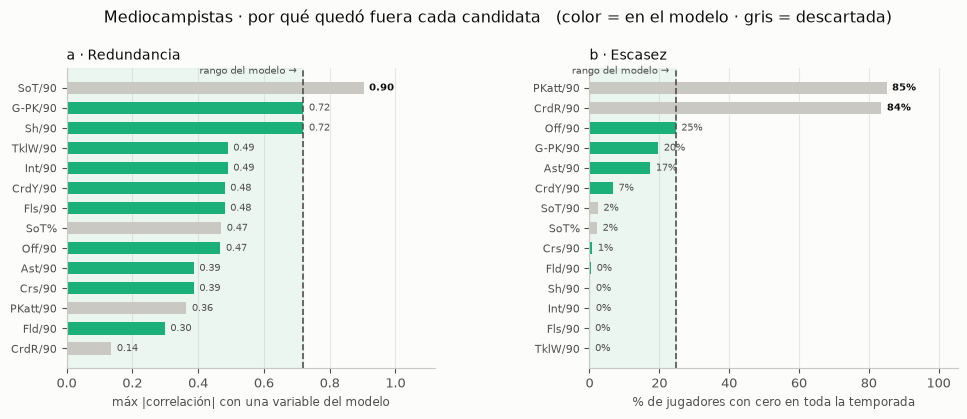

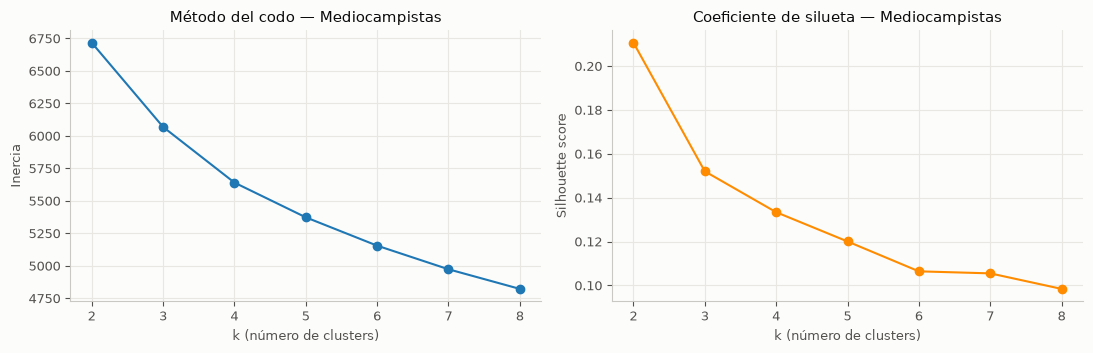

 k  inercia  silueta
 2   6718.0    0.211
 3   6069.6    0.152
 4   5641.1    0.133
 5   5373.8    0.120
 6   5155.7    0.106
 7   4973.9    0.106
 8   4822.8    0.098

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 4

=== Mediocampistas — k=4 | n=1143 | silhouette=0.133 ===
    878 de entrenamiento (silueta 0.133) | 265 etiquetados por predicción (silueta del conjunto completo 0.123)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                271       198
1                268       220
2                279       216
3                325       244


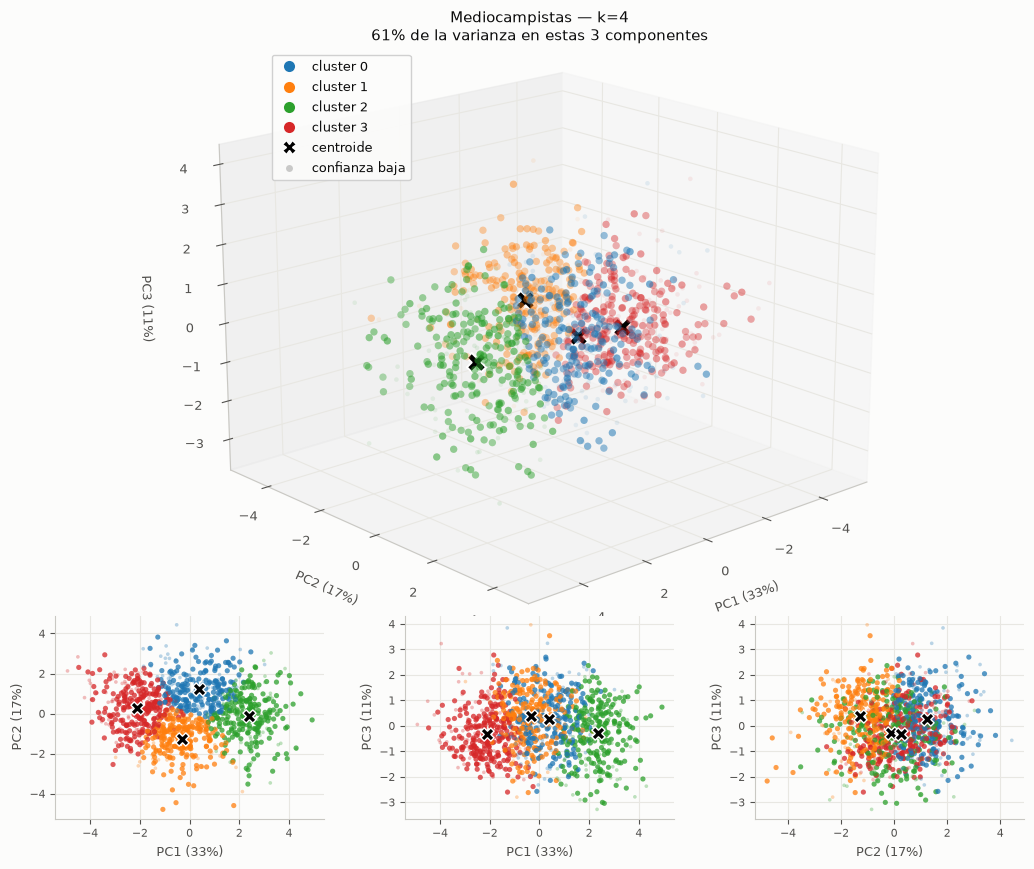

,varianza explicada,acumulada
PC1,32.8%,32.8%
PC2,16.8%,49.5%
PC3,11.4%,60.9%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
Int/90,-0.40,-0.04,0.08
TklW/90,-0.36,0.19,0.27
Fls/90,-0.16,0.60,0.02
Fld/90,0.13,0.47,0.14
CrdY/90,-0.22,0.48,0.18
Crs/90,0.22,-0.15,0.71
Off/90,0.37,0.12,0.03
Ast/90,0.30,-0.03,0.51
G-PK/90,0.40,0.22,-0.29
Sh/90,0.44,0.25,-0.13


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2,cluster 3
Int/90,0.762,0.621,0.832,0.412,1.122
TklW/90,1.039,1.076,1.033,0.650,1.346
Fls/90,1.222,1.541,0.870,0.971,1.463
Fld/90,1.259,1.712,0.865,1.368,1.112
CrdY/90,0.195,0.277,0.121,0.112,0.259
Crs/90,2.326,2.538,3.062,2.796,1.137
Off/90,0.166,0.205,0.107,0.327,0.045
Ast/90,0.116,0.125,0.119,0.180,0.050
G-PK/90,0.125,0.152,0.062,0.255,0.044
Sh/90,1.408,1.632,0.975,2.324,0.790


Composición de cada cluster por posición reportada (%):


pos,"DF,MF","FW,MF",MF,"MF,DF","MF,FW"
cluster,,,,,
0,2.2,10.7,56.8,5.5,24.7
1,19.0,1.1,53.0,17.5,9.3
2,0.7,26.5,34.8,0.7,37.3
3,19.1,0.3,67.7,10.5,2.5


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Nikola Vlašić, Adrien Rabiot, Marco Grüll, Crysencio Summerville, Sebastiano Esposito, Tyrhys Dolan
  cluster 1: Marcel Sabitzer, Diogo Dalot, Andrea Cambiaso, Mattéo Tramoni, Danny da Costa, Lucas Da Cunha
  cluster 2: Jaidon Anthony, Arthur Atta, Mohamed Ali Cho, Viktor Tsyhankov, Marcus Tavernier, Leandro Trossard
  cluster 3: Michel Aebischer, Ethan Ampadu, Ayyoub Bouaddi, Urko González, Miguel Román, Jesper Karlström

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Warren Kamanzi,Toulouse,24.0,870.0,1,1.25
1,Chris Rigg,Sunderland,18.0,761.0,2,1.74
2,Bahereba Guirassy,Nantes,18.0,821.0,0,1.80
3,Rodrigo Riquelme,Real Betis,25.0,821.0,0,1.82
4,Sávio,Manchester City,21.0,833.0,2,1.85
5,Brajan Gruda,Brighton,21.0,719.0,0,1.89
6,Oier Zarraga,Udinese,26.0,475.0,3,1.90
7,Hamed Junior Traorè,Marseille,25.0,619.0,2,1.91


Mediocampistas  -> jugadores_MF_con_cluster.csv, perfil_clusters_MF.csv, modelo_MF.joblib


In [14]:
# ===== FASES 3 a 6 — el modelo de mediocampistas de principio a fin =====
# El código está en models/modelo_mf.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_mf

modelos["MF"] = modelo_mf.main(datasets=datasets)

### Interpretación

**k=4 · silhouette 0.133** (878 de entrenamiento) · **0.123** (1143 etiquetados). Sigue siendo de los más bajos, esperable en un mediocampo que es un continuo de roles más que categorías separadas.

Los cuatro perfiles de 2023-24 **reaparecen íntegros**, aunque con otra numeración: es la posición más estable entre temporadas.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **3** | **Pivote destructor** | 325 | Máximos en `Int`/90 (1.12) y `TklW`/90 (1.35); mínimos en `Crs`/90 (1.14), `Off`/90 (0.045), `Ast`/90 (0.050), `G-PK`/90 (0.044) y `Sh`/90 (0.79). Casi nunca pisa el área rival. 67.7 % `MF` puro | Aebischer, Ampadu, Bouaddi, Urko González, Karlström, Eric García |
| **2** | **Interior ofensivo** | 279 | Lidera `Off`/90 (0.327), `Ast`/90 (0.180), `G-PK`/90 (0.255) y `Sh`/90 (2.32); mínimos en `Int`/90 (0.412), `TklW`/90 (0.650) y amarillas (0.112). 63.8 % `MF,FW`/`FW,MF` | Jaidon Anthony, Arthur Atta, Cho, Tsyhankov, Trossard, Nico Williams |
| **1** | **Carrilero** | 268 | `Crs`/90 el más alto (3.06) pero sin llegada: `Sh`/90 0.98, `G-PK`/90 0.062, `Off`/90 0.107 y el `Fld`/90 más bajo (0.865). 36.5 % `DF,MF`/`MF,DF` | Sabitzer, Dalot, Cambiaso, Da Costa, Çelik |
| **0** | **Interior de conducción** | 271 | Máximos en `Fld`/90 (1.71) y `Fls`/90 (1.54) — el de mayor roce en ambas direcciones — con remate sobre la media (`Sh`/90 1.63) y `CrdY`/90 el más alto (0.277) | Vlašić, Rabiot, Grüll, Summerville, Esposito, Dolan |

- **El eje que ordena el mediocampo** va del cluster 3 al 2: `Int`/90 correlaciona −0.45 con `Sh`/90, así que recuperar y rematar son los dos polos de un continuo.
- Los clusters 1 y 0 son posiciones intermedias que se distinguen por *cómo* participan: el 1 por banda y sin llegada, el 0 por el centro y a base de roce.
- **Cruce con la sección 7:** el cluster 2 concentra a la mayoría de los `MF,FW`/`FW,MF` — señal de que el modelo captura su polivalencia ofensiva. Contrastar con la tabla `polivalentes_clusters` de la sección 8.

**La PCA describe bien esos dos ejes.**
- **PC1 (32.8 %)** — destrucción ↔ llegada: `Sh`/90 (+0.44), `G-PK`/90 (+0.40), `Off`/90 (+0.37) contra `Int`/90 (−0.40) y `TklW`/90 (−0.36).
- **PC2 (16.8 %)** — roce: `Fls`/90 (+0.60), `CrdY`/90 (+0.48), `Fld`/90 (+0.47). Es lo que aísla al cluster 0.

> ⚠️ Con silhouette 0.133, el mediocampo sigue siendo de las posiciones con menos fronteras naturales entre roles. Etiquetas de trabajo, no veredicto.

---
## 7. Modelo de delanteros (FW)

### Fase 3 · variables (10)

| Bloque | Variables |
|---|---|
| **Finalización** | `G-PK`/90, `Sh`/90, `SoT%` |
| **Movimiento** | `Off`/90 (fueras de juego) |
| **Juego de banda** | `Crs`/90 (centros), `Ast`/90 |
| **Conducción** | `Fld`/90 (faltas recibidas) |
| **Trabajo sin balón** | `Int`/90, `TklW`/90, `Fls`/90 |

- **`Off`/90** es el marcador del **delantero de ruptura**: caer en fuera de juego es el precio de atacar el espacio a la espalda de la defensa, y separa al nueve de área del extremo que recibe de cara. Media 0.42 por 90 y solo 4.5 % a cero.
- **`Int`/90 y `TklW`/90** son un bloque deliberado: distinguen al **atacante que presiona** del finalizador puro. Correlacionan −0.18 y −0.30 con `Sh`/90 — dentro del ataque, defender y rematar tiran en direcciones opuestas. Es el eje que interesa a un scouting que busca delantero para presión alta.
- **`Sh`/90 + `SoT%`, no `SoT`/90.** Es la **única posición donde `SoT%` entra**, porque es donde todos rematan lo suficiente para que la puntería signifique algo: quitarla reorganiza la partición (ARI 0.70). Y la separación es la más limpia de todas — `Sh`/90 y `SoT%` correlacionan **0.12**, dos dimensiones casi independientes que juntas describen el perfil de tiro mejor que cualquiera por separado.

### Lo que queda fuera

| Variable | Motivo |
|---|---|
| `PKatt`/90 | El 59 % no lanza ninguno, y quien lanza es porque el club se lo asigna: decisión de vestuario, no forma de jugar |
| `CrdY`/90 | Correlaciona 0.40 con `Fls`/90 y las tarjetas no marcan rol de ataque. En DF y MF sí aportan |
| `SoT`/90, `G/Sh` | Redundantes con `Sh`/90 (0.85) y `G-PK`/90 (0.57) |

En la figura siguiente, `SoT`/90 y `G/Sh` rebasan la banda de **redundancia**, y `CrdR`/90 (87 %) y `PKatt`/90 (59 %) la de **escasez**. `CrdY`/90 cabe dentro de ambas: se descartó porque añadirla baja la silueta sin aportar un rol nuevo.

> Este dataset incluye a los `MF,FW` y `FW,MF`, que también se evalúan en la sección 6.

### Fases 4-5

| `k` | Silhouette 2023-24 | Silhouette 2025-26 |
|---|---|---|
| 2 | — | 0.200 |
| 3 | 0.160 | 0.150 |
| 4 | 0.134 | 0.116 |
| **5** | **0.132** | **0.109** |
| 6 | 0.116 | 0.108 |

- En 2023-24 el quinto perfil salía **prácticamente gratis** (0.134 → 0.132) y el sexto costaba claramente (0.116): cinco era un techo natural que la curva marcaba sola.
- **En 2025-26 esa curva ya no dice lo mismo.** El salto caro está antes (3 → 4: 0.150 → 0.116) y de 5 a 6 la caída es de 0.001: la silueta **no distingue** entre cinco y seis perfiles.
- Se mantiene `k=5` por continuidad con la temporada anterior y porque los cinco perfiles siguen siendo interpretables (ver abajo), **no porque la métrica lo respalde**. Es la decisión más discutible de las cuatro.
- Centroides con los **380 de entrenamiento**; etiquetados **511**.

Dataset Delanteros: 511 jugadores (380 de entrenamiento)


  6 de 10 columnas convertidas a por-90 | 0 faltantes imputados | escalado: yeo-johnson
  Matriz final: 511 jugadores × 10 variables (380 de entrenamiento, 131 de confianza baja)


,% ceros,asimetría por-90,asimetría escalada,max |z| (entren.),max |z| (todos)
G-PK/90,9.6,0.77,0.02,2.77,2.77
Ast/90,21.5,0.93,0.08,2.64,2.80
Sh/90,0.0,0.64,0.00,3.22,3.22
SoT%,0.4,0.01,0.01,3.03,4.22
Off/90,7.6,1.28,0.05,2.66,2.66
Crs/90,3.9,1.25,0.08,2.00,2.00
Fld/90,0.4,0.87,-0.00,3.01,3.01
Fls/90,0.0,0.58,-0.00,2.80,2.82
Int/90,6.7,0.94,0.07,2.28,2.28
TklW/90,1.4,0.99,0.01,2.71,2.72


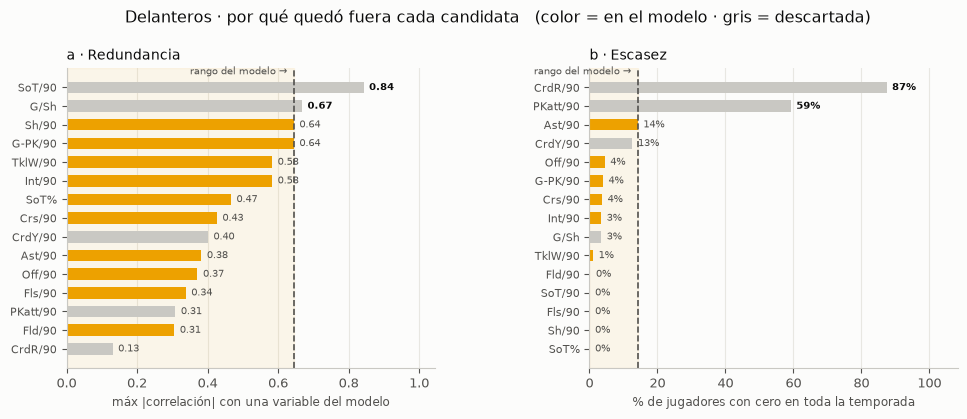

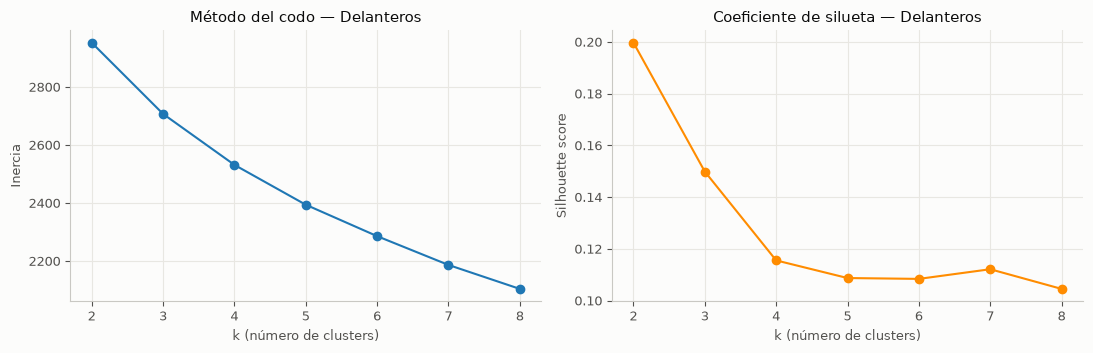

 k  inercia  silueta
 2   2952.8    0.200
 3   2707.2    0.150
 4   2531.6    0.116
 5   2394.2    0.109
 6   2285.9    0.108
 7   2186.6    0.112
 8   2104.1    0.105

k con mejor silueta (solo referencia): 2
k sugerido por silueta: 2  |  k elegido: 5

=== Delanteros — k=5 | n=511 | silhouette=0.109 ===
    380 de entrenamiento (silueta 0.109) | 131 etiquetados por predicción (silueta del conjunto completo 0.098)

Tamaño de cada cluster (etiquetados / de los cuales entrenan):
         etiquetados  entrenan
cluster                       
0                101        83
1                129        93
2                 87        66
3                 94        61
4                100        77


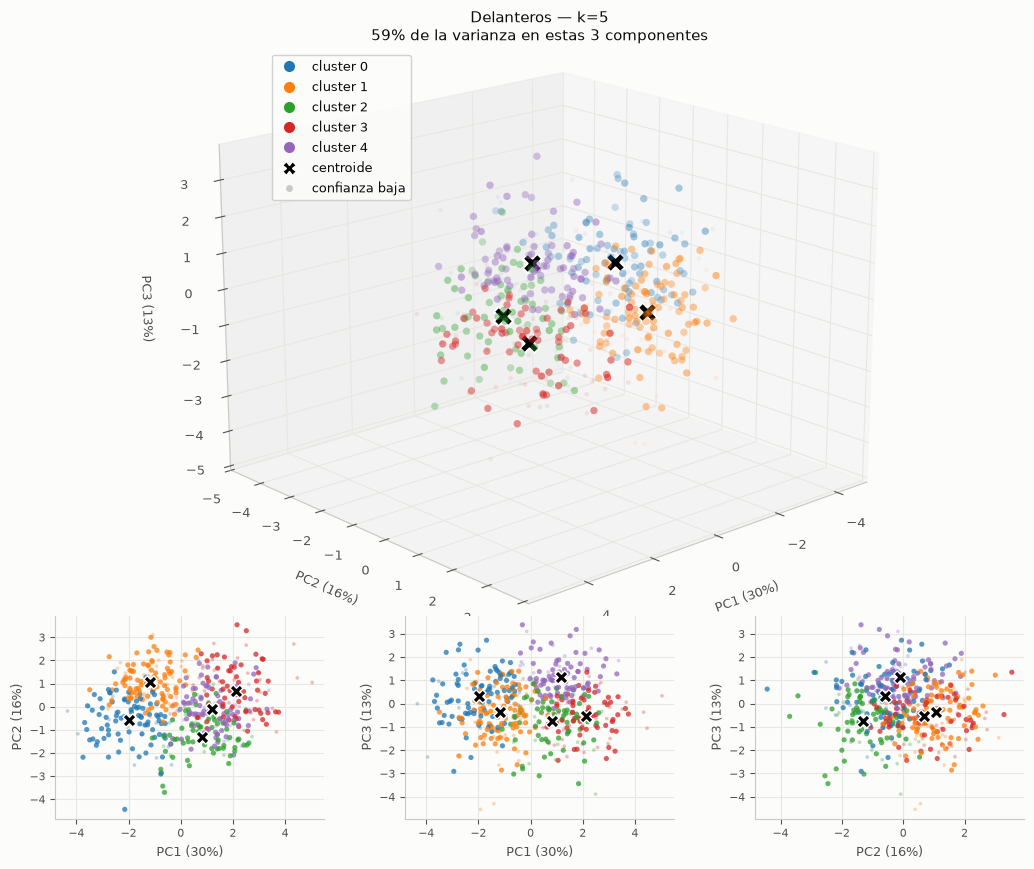

,varianza explicada,acumulada
PC1,30.1%,30.1%
PC2,15.5%,45.6%
PC3,13.2%,58.9%


Cargas de cada variable en las componentes (signo = dirección del eje):


,PC1,PC2,PC3
G-PK/90,-0.42,-0.18,0.37
Ast/90,0.14,-0.40,0.44
Sh/90,-0.32,-0.19,0.52
SoT%,-0.30,-0.22,-0.02
Off/90,-0.35,0.14,0.01
Crs/90,0.40,-0.36,0.06
Fld/90,0.12,0.38,0.47
Fls/90,-0.07,0.64,0.23
Int/90,0.36,-0.00,0.26
TklW/90,0.42,0.12,0.24


Perfil medio de cada cluster (valores por 90 minutos, sin escalar):


,media global,cluster 0,cluster 1,cluster 2,cluster 3,cluster 4
G-PK/90,0.258,0.496,0.248,0.172,0.108,0.245
Ast/90,0.130,0.138,0.070,0.159,0.080,0.221
Sh/90,2.297,3.047,2.279,2.021,1.584,2.474
SoT%,37.781,44.559,38.808,38.347,30.753,35.724
Off/90,0.419,0.567,0.636,0.292,0.239,0.268
Crs/90,1.851,0.706,0.564,3.811,2.239,2.596
Fld/90,1.424,1.081,1.499,1.036,1.388,2.045
Fls/90,1.296,1.184,1.632,0.794,1.419,1.294
Int/90,0.348,0.216,0.206,0.276,0.598,0.492
TklW/90,0.651,0.391,0.436,0.571,1.079,0.856


Composición de cada cluster por posición reportada (%):


pos,FW,"FW,MF","MF,FW"
cluster,,,
0,77.2,15.8,6.9
1,76.0,20.2,3.9
2,6.9,26.4,66.7
3,4.3,16.0,79.8
4,14.0,27.0,59.0


Jugadores más representativos de cada cluster (solo de entrenamiento):
  cluster 0: Ollie Watkins, Toni Martínez, Callum Wilson, Odsonne Édouard, Patrik Schick, Ragnar Ache
  cluster 1: Olivier Giroud, Mbwana Samatta, Roberto Férnandez, Shuto Machino, Walid Cheddira, Habib Diallo
  cluster 2: Arnaut Danjuma, Ibrahim Mbaye, Mohamed Ali Cho, Charles De Ketelaere, Moses Simon, Jacob Murphy
  cluster 3: Nikola Vlašić, Diego López, Marco Grüll, Adam Daghim, Kaoru Mitoma, Fer López
  cluster 4: Jonathan Rowe, Issa Soumaré, Jeremy Doku, Maghnes Akliouche, Gabriel Strefezza, Jean Mattéo Bahoya

Confianza baja mejor encajados en su perfil (candidatos a revisar):


,player,team,age,Playing Time_Min,cluster,dist_centroide
0,Armando Broja,Burnley,23.0,860.0,1,1.72
1,Tim Skarke,Union Berlin,28.0,623.0,2,1.79
2,Ignatius Ganago,Nantes,26.0,839.0,1,1.83
3,Malick Fofana,Lyon,20.0,749.0,4,1.84
4,Neal Maupay,Sevilla,28.0,865.0,1,1.91
5,Johan Bakayoko,RB Leipzig,22.0,777.0,1,1.93
6,Evan Ferguson,Roma,20.0,773.0,0,1.95
7,Stefan Schimmer,Heidenheim,31.0,820.0,0,1.95


Delanteros      -> jugadores_FW_con_cluster.csv, perfil_clusters_FW.csv, modelo_FW.joblib


In [15]:
# ===== FASES 3 a 6 — el modelo de delanteros de principio a fin =====
# El código está en models/modelo_fw.py: prepara las variables, elige k, ajusta el
# K-Means, lo evalúa y exporta el dataset etiquetado, la tabla de perfiles y el .joblib.
from models import modelo_fw

modelos["FW"] = modelo_fw.main(datasets=datasets)

### Interpretación

**k=5 · silhouette 0.109** (380 de entrenamiento) · **0.098** (511 etiquetados) — el más bajo de los cuatro modelos.

Dos familias —nueves y extremos— pero repartidas distinto que en 2023-24: ahora son **dos tipos de nueve y tres de extremo**.

| Cluster | Perfil | n | Rasgos | Representativos |
|---|---|---|---|---|
| **0** | **Nueve goleador** | 101 | Máximos en `G-PK`/90 (0.496, casi el doble de la media), `Sh`/90 (3.05) y `SoT%` (44.6 %); mínimos en `Crs`/90 (0.706), `Int`/90 (0.216) y `TklW`/90 (0.391). 77.2 % `FW` puro | Watkins, Toni Martínez, Callum Wilson, Édouard, Schick, Balogun |
| **1** | **Nueve de choque** | 129 | `Off`/90 el más alto (0.636) y `Fls`/90 también (1.63), pero convierte poco: `G-PK`/90 0.248 con `Sh`/90 2.28. `Ast`/90 el más bajo (0.070) y `Crs`/90 mínimo (0.564). 76.0 % `FW` puro | Giroud, Samatta, Roberto Fernández, Machino, Cheddira, Diallo |
| **2** | **Extremo centrador** | 87 | `Crs`/90 = 3.81, más del doble de la media (1.85); `Fls`/90 el más bajo (0.794) y `Fld`/90 también (1.04). 93.1 % polivalentes | Danjuma, Mbaye, Cho, De Ketelaere, Moses Simon, Pedro Neto |
| **3** | **Extremo de presión** | 94 | Lidera `Int`/90 (0.598) y `TklW`/90 (1.08); el remate más bajo de los cinco (`Sh`/90 1.58, `G-PK`/90 0.108, `SoT%` 30.8 %). 95.8 % polivalentes | Vlašić, Diego López, Grüll, Daghim, Mitoma, Fer López |
| **4** | **Extremo regateador** | 100 | `Ast`/90 el más alto (0.221) y `Fld`/90 también (2.05, un 44 % sobre la media); `Crs`/90 2.60 y trabajo defensivo por encima de la media (`Int`/90 0.492, `TklW`/90 0.856). 86.0 % polivalentes | Rowe, Soumaré, Doku, Akliouche, Strefezza, Bahoya, Pépé |

**El contraste 0 vs. 1 es el más accionable.**
- Los dos son nueves puros (77 % y 76 % `FW` sin segunda posición) y los dos atacan el espacio.
- El **0** remata más (3.05 vs. 2.28) y sobre todo **acierta más** (44.6 % vs. 38.8 %): marca el doble por 90.
- El **1** cae más en fuera de juego y comete más faltas — pelea la misma zona sin convertirla.
- Para un informe de fichajes no son intercambiables aunque ocupen el mismo sitio en el campo: uno resuelve y el otro desgasta.

**Los tres extremos se separan por lo que hacen sin gol** (los tres marcan poco: 0.17, 0.11 y 0.25 por 90): el **2** centra, el **3** presiona y el **4** desborda y asiste. `Fld`/90 es lo que aísla al 4 —2.05 frente a 1.04 del centrador—: al regateador lo derriban.

**`Sh`/90 × `SoT%` con cinco grupos:** cluster 0 = volumen alto + mejor puntería (44.6 %); cluster 1 = volumen medio + puntería media (38.8 %); cluster 3 = volumen bajo + la peor puntería (30.8 %). Es el cruce que justifica haber elegido `Sh`/90 y `SoT%` en lugar de `Sh`/90 y `SoT`/90.

> ⚠️ **Es el modelo más frágil de los cuatro.** Silhouette 0.109, y la curva de `k` ya no señala cinco como techo (ver arriba). Los tres perfiles de extremo son coherentes uno a uno, pero conviene tratarlos como matices de un mismo rol antes que como categorías cerradas.

---
## 8. Evaluación comparativa y despliegue (*Evaluation* · *Deployment*)

Las cuatro secciones anteriores evaluaron cada modelo por separado. Aquí se comparan entre sí y se exporta todo lo necesario para reutilizar el análisis.

> ⚠️ **El `silhouette` no es comparable entre posiciones.** Cada modelo trabaja en un espacio distinto, con distinto número de variables y de jugadores. Un silhouette bajo en mediocampistas no significa peor modelo, sino que el mediocampo es un continuo de roles sin fronteras naturales — exactamente lo que uno esperaría del fútbol. Sirve para comparar `k` **dentro** de una posición, no entre posiciones.

In [16]:
# --- Comparación de los 4 modelos ------------------------------------------------------
mostrar(modelado.comparar_modelos(modelos))

total_perfiles = sum(modelos[p]["k"] for p in P.POSICIONES)
print(f"Total de perfiles identificados en las 4 posiciones: {total_perfiles}")

# --- Los polivalentes, vistos desde sus dos modelos ------------------------------------
# Un jugador "DF,MF" tiene un cluster como defensa y otro como mediocampista. Esta tabla
# los pone lado a lado: es la lectura más útil del enfoque por posición, porque muestra
# qué rol cumple el mismo futbolista según desde qué línea se le mire.
polivalentes_clusters = modelado.clusters_de_polivalentes(modelos, polivalentes)

print(f"\nJugadores polivalentes con doble etiqueta: {len(polivalentes_clusters)}")
mostrar(polivalentes_clusters.head(15))

,posición,n_etiquetados,n_entrenan,n_variables,k,sil_entren.,sil_todos,cluster más grande,cluster más pequeño
0,Porteros,139,105,5,3,0.210,0.179,70,33
1,Defensas,735,605,8,3,0.148,0.149,250,235
2,Mediocampistas,1143,878,10,4,0.133,0.123,325,268
3,Delanteros,511,380,10,5,0.109,0.098,129,87


Total de perfiles identificados en las 4 posiciones: 15



Jugadores polivalentes con doble etiqueta: 530


,player,team,pos,cluster_DF,cluster_MF,cluster_FW
0,Bukayo Saka,Arsenal,"FW,MF",<NA>,2,4
1,Eberechi Eze,Arsenal,"MF,FW",<NA>,2,4
2,Gabriel Martinelli,Arsenal,"FW,MF",<NA>,2,2
3,Kai Havertz,Arsenal,"FW,MF",<NA>,2,4
4,Leandro Trossard,Arsenal,"FW,MF",<NA>,2,4
5,Mikel Merino,Arsenal,"MF,FW",<NA>,0,4
6,Myles Lewis-Skelly,Arsenal,"MF,DF",1,3,<NA>
7,Noni Madueke,Arsenal,"FW,MF",<NA>,2,2
8,Donyell Malen,Aston Villa,"FW,MF",<NA>,2,0
9,Lamare Bogarde,Aston Villa,"MF,DF",1,3,<NA>


In [17]:
# --- Exportación -----------------------------------------------------------------------
# Ya está hecha: cada models/modelo_*.py llama a modelado.exportar() al terminar, así que
# ejecutar este notebook y ejecutar `python -m models.entrenar_todos` dejan exactamente
# los mismos archivos. Aquí solo se comprueba qué hay en disco.
#
# El .joblib guarda, además de imputer/scaler/kmeans/pca, qué columnas hay que convertir
# a por-90 (y sobre qué columna de minutos): sin ese detalle el bundle no bastaría para
# etiquetar a un jugador nuevo siguiendo el mismo pipeline de la fase 3.
filas = []
for p in P.POSICIONES:
    for ruta in (R.csv_jugadores(p), R.csv_perfil(p), R.joblib_modelo(p)):
        filas.append({"posición": P.NOMBRE_POS[p],
                      "archivo": str(ruta.relative_to(R.RAIZ)),
                      "existe": ruta.exists(),
                      "KB": round(ruta.stat().st_size / 1024, 1) if ruta.exists() else None})

mostrar(pd.DataFrame(filas))

n_figuras = len(list(R.FIGURAS.glob("*.png")))
print(f"\n✅ {len(filas)} archivos exportados y {n_figuras} figuras en "
      f"{R.FIGURAS.relative_to(R.RAIZ)}/")

,posición,archivo,existe,KB
0,Porteros,reports\jugadores_GK_con_cluster.csv,True,53.0
1,Porteros,reports\perfil_clusters_GK.csv,True,0.5
2,Porteros,models\entrenados\modelo_GK.joblib,True,4.6
3,Defensas,reports\jugadores_DF_con_cluster.csv,True,252.3
4,Defensas,reports\perfil_clusters_DF.csv,True,0.7
5,Defensas,models\entrenados\modelo_DF.joblib,True,7.1
6,Mediocampistas,reports\jugadores_MF_con_cluster.csv,True,394.8
7,Mediocampistas,reports\perfil_clusters_MF.csv,True,1.1
8,Mediocampistas,models\entrenados\modelo_MF.joblib,True,8.6
9,Delanteros,reports\jugadores_FW_con_cluster.csv,True,177.8



✅ 12 archivos exportados y 15 figuras en reports\figuras/


### Conclusiones

**Alcance.** Cuatro modelos de clustering independientes sobre las 5 grandes ligas europeas (**2025-26**), con **15 perfiles** en total.

- Perfiles entrenados con quien jugó al menos **10 partidos completos** (15 en porteros) y etiquetado extendido a todo el que supere **5 partidos**, marcando su confianza — sección 3.1.
- **1968 apariciones de entrenamiento**, **2528 etiquetadas**, sobre **1998 jugadores distintos**, entre ellos **322 de 21 años o menos** y **530 polivalentes**.

**Porteros — k=3, silhouette 0.210**
- Dos clusters son las puntas del eje de exigencia: de poco expuesto y con buenos resultados (`CS%` 42.9 %) a muy exigido y superado (`CS%` 12.4 %).
- El tercero, el más numeroso, se define por el `Fld`/90 más alto con todo lo demás en la media: **sale a disputar más**. Es el único perfil de *estilo*, pero su ventaja se redujo respecto a 2023-24 y ahora agrupa a la mitad de la posición.

**Defensas — k=3, silhouette 0.148**
- **La estructura cambió respecto a 2023-24**: ya no es un central frente a dos tipos de lateral, sino un lateral frente a **dos maneras de ser central** — posicional (por debajo de la media en las ocho variables) y de combate (máximos en intercepciones, faltas y amarillas).
- La decisión de retirar `G-PK`/90, sólida en 2023-24, **no se sostiene con estos datos** (ARI 0.55 en vez de 0.91).

**Mediocampistas — k=4, silhouette 0.133**
- **La posición más estable entre temporadas**: los cuatro perfiles reaparecen íntegros (pivote destructor, carrilero, interior de conducción e interior ofensivo), solo cambia su numeración.
- El interior ofensivo concentra la mayoría de los polivalentes `MF,FW`.
- La retirada de `SoT%` se confirma con evidencia casi idéntica (ARI 0.92 vs. 0.91).

**Delanteros — k=5, silhouette 0.109**
- Dos tipos de nueve (goleador y de choque) y **tres** de extremo (centrador, de presión y regateador).
- Contraste más útil: los dos nueves ocupan la misma zona y uno marca el doble que el otro con mejor puntería.
- **Es el modelo más frágil**: la curva de `k` ya no justifica cinco perfiles, y se mantienen por continuidad e interpretabilidad, no por métrica.

### Qué aportó cambiar de temporada

Repetir el mismo pipeline sobre 2025-26 funcionó como una prueba de robustez que el diseño original no tenía:

| | Resultado |
|---|---|
| Esquema de datos | **Idéntico**: 75 columnas, las 33 variables de los modelos presentes |
| Numeración de clusters | **No se conserva** — en porteros rotó entera |
| Estructura de perfiles | Estable en MF; **cambió en DF**; se redistribuyó en FW |
| Decisiones de variables | `SoT%` en MF se confirma; **`G-PK`/90 en DF se desmiente** |
| Siluetas | Sube en GK (0.188 → 0.210), baja en las otras tres |

Que los perfiles de mediocampo reaparezcan intactos con datos de otra temporada es la mejor evidencia de que ese modelo captura roles reales y no ruido. Que los de defensa se reorganicen es la evidencia contraria, y hay que decirlo igual.

### Qué NO puede concluirse

- El enfoque por posición **no se comparó cuantitativamente** contra un clustering global: ese modelo no se entrenó aquí, así que la justificación sigue siendo conceptual (sección 1).
- La comparación entre temporadas es **descriptiva, no una prueba de estabilidad formal**: no se midió el ARI entre la partición de 2023-24 y la de 2025-26 sobre los jugadores comunes.
- Los nombres de los perfiles **no se validaron** con criterio de scouting cualitativo externo.
- Con silhouettes entre 0.11 y 0.21, **los límites entre clusters vecinos no son tajantes** en ninguna posición, y en delanteros son especialmente porosos.
- **Limitación de variables:** sin `passing`, `possession`, `defense` y `keeper_adv` no hay xG, pases progresivos, regates ni duelos aéreos. La creación de juego queda poco representada (solo centros y asistencias) y el modelo de porteros no puede perfilar estilo con balón.

### Próximos pasos

1. **Reabrir `G-PK`/90 en defensas** — es lo único que la nueva temporada dejó explícitamente mal. Reentrenar el modelo con las 9 variables y comparar perfiles y silueta.
2. **Ampliar las métricas** — añadir `passing`, `possession` y `defense` (campo) y `keeper_adv` (porteros) a `FBREF_TABLAS` en `config/parametros.py`. Es la mejora de mayor impacto sobre los cuatro modelos.
3. **Medir la estabilidad entre temporadas** — cruzar las etiquetas de 2023-24 y 2025-26 sobre los jugadores presentes en ambas y calcular el ARI. Convertiría la comparación descriptiva de arriba en una métrica.
4. **Revisar `k` en delanteros** — la silueta ya no distingue entre 5 y 6 perfiles. Decidirlo con criterio futbolístico explícito o bajar a `k=3`, que es donde la curva aún marca un salto.
5. **Comparar K-Means con otros algoritmos** — jerárquico (*Agglomerative*), o `DBSCAN` si interesa que los atípicos queden sin asignar en vez de forzarlos a un perfil.